<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Cohort_data_visualization_and_RFM_analysis_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Cohort data visualization and RFM analysis - Exercises**
---

A company selling bicycle equipment called BikeStore wants to conduct an analysis based on its data from the previous year, 2017.

You work as a data scientist at this company. You are given a dataset containing a list of transactions during 2017 and are asked to perform some analysis.

### **Number 1**

Before performing the analysis, display the [store_bike.csv](https://github.com/harishmuh/Python-for-Data-Science-Analysis/blob/main/datasets/store_bike.csv) dataset!

- Inside the dataset, there is a 'transaction_date' column containing the transaction date. Change its data type from object to datetime!
- Then, delete all rows with missing values from the dataframe!
- Then, select only transactions whose order_status is 'Approved'!

In [3]:
# Importing libraries

# Data manipulation
import numpy as np
import pandas as pd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

# settings
import warnings
warnings.filterwarnings('ignore')

Change the data of the column 'transaction_date' from object to datetime

In [4]:
# Loading dataset
store_bike_url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/store_bike.csv'
df = pd.read_csv(store_bike_url, parse_dates=['transaction_date'], infer_datetime_format=True)
df.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,$53.62,41245.0
1,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,$388.92,41701.0
2,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,$248.82,36361.0
3,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,$381.10,36145.0
4,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,$709.48,42226.0


Removes all rows that have missing values from the dataframe.

In [5]:
df_clean = df.dropna().copy()
df_clean

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,$53.62,41245.0
1,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,$388.92,41701.0
2,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,$248.82,36361.0
3,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,$381.10,36145.0
4,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,$709.48,42226.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,2005.66,"$1,203.40",37823.0
19996,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,416.98,$312.74,35560.0
19997,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,$44.71,40410.0
19998,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,227.88,$136.73,38216.0


Select only transactions whose order_status is 'Approved'.

In [6]:
df_clean = df_clean[df_clean['order_status']=='Approved'].copy()
df_clean['order_status'].unique()

array(['Approved'], dtype=object)

### **Number 2**

The marketing department has asked you to analyze customer behavior during 2017. Try conducting a cohort analysis based on the data provided. How did BikeStore customers behave during 2017?

**Period**

In [7]:
df_clean['transaction_period'] = df_clean['transaction_date'].dt.to_period('M')
df_clean.sample(5, random_state=42)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,transaction_period
1545,1546,70,1134,2017-05-01,True,Approved,Trek Bicycles,Standard,high,medium,495.72,$297.43,42105.0,2017-05
4279,4280,29,1998,2017-07-05,False,Approved,WeareA2B,Standard,medium,medium,1065.03,$230.09,33549.0,2017-07
1608,1609,87,1241,2017-09-18,False,Approved,Giant Bicycles,Standard,high,medium,1179.00,$707.40,34079.0,2017-09
6292,6293,10,124,2017-03-18,True,Approved,Solex,Standard,medium,medium,1945.43,$333.18,40553.0,2017-03
7999,8000,40,2257,2017-05-21,False,Approved,OHM Cycles,Standard,high,medium,1458.17,$874.90,38750.0,2017-05


**Cohort Group**

In [8]:
df_clean['cohort_group'] = df_clean.groupby('customer_id')['transaction_date'].transform('min').dt.to_period('M')
df_clean.sample(5, random_state=42)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,transaction_period,cohort_group
1545,1546,70,1134,2017-05-01,True,Approved,Trek Bicycles,Standard,high,medium,495.72,$297.43,42105.0,2017-05,2017-02
4279,4280,29,1998,2017-07-05,False,Approved,WeareA2B,Standard,medium,medium,1065.03,$230.09,33549.0,2017-07,2017-02
1608,1609,87,1241,2017-09-18,False,Approved,Giant Bicycles,Standard,high,medium,1179.00,$707.40,34079.0,2017-09,2017-02
6292,6293,10,124,2017-03-18,True,Approved,Solex,Standard,medium,medium,1945.43,$333.18,40553.0,2017-03,2017-03
7999,8000,40,2257,2017-05-21,False,Approved,OHM Cycles,Standard,high,medium,1458.17,$874.90,38750.0,2017-05,2017-04


**Number of Unique Customers**

In [9]:
cohort = df_clean.groupby(['cohort_group', 'transaction_period'], as_index=False).agg(n_customers=('customer_id', 'nunique'))
cohort

,cohort_group,transaction_period,n_customers
0,2017-01,2017-01,1315
1,2017-01,2017-02,461
2,2017-01,2017-03,475
3,2017-01,2017-04,474
4,2017-01,2017-05,470
...,...,...,...
73,2017-10,2017-11,6
74,2017-10,2017-12,7
75,2017-11,2017-11,15
76,2017-11,2017-12,6


**Period Distance**

In [10]:
cohort['period_distance'] = (cohort['transaction_period'] - cohort['cohort_group']).apply(lambda x : x.n)
cohort

,cohort_group,transaction_period,n_customers,period_distance
0,2017-01,2017-01,1315,0
1,2017-01,2017-02,461,1
2,2017-01,2017-03,475,2
3,2017-01,2017-04,474,3
4,2017-01,2017-05,470,4
...,...,...,...,...
73,2017-10,2017-11,6,1
74,2017-10,2017-12,7,2
75,2017-11,2017-11,15,0
76,2017-11,2017-12,6,1


**Cohort Size and Percentage**

In [11]:
cohort['cohort_size'] = cohort.groupby('cohort_group')['n_customers'].transform('max')
cohort['percentage'] = (cohort['n_customers']/cohort['cohort_size'] * 100).round(2)
cohort

,cohort_group,transaction_period,n_customers,period_distance,cohort_size,percentage
0,2017-01,2017-01,1315,0,1315,100.00
1,2017-01,2017-02,461,1,1315,35.06
2,2017-01,2017-03,475,2,1315,36.12
3,2017-01,2017-04,474,3,1315,36.05
4,2017-01,2017-05,470,4,1315,35.74
...,...,...,...,...,...,...
73,2017-10,2017-11,6,1,22,27.27
74,2017-10,2017-12,7,2,22,31.82
75,2017-11,2017-11,15,0,15,100.00
76,2017-11,2017-12,6,1,15,40.00


**Pivot Table**

In [12]:
cohort_pivot = cohort.pivot_table(
    index = 'cohort_group',
    columns = 'period_distance',
    values = 'percentage'
)

cohort_pivot

period_distance,0,1,2,3,4,5,6,7,8,9,10,11
cohort_group,,,,,,,,,,,,
2017-01,100.0,35.06,36.12,36.05,35.74,34.60,37.11,37.87,35.67,37.72,35.44,37.19
2017-02,100.0,38.66,36.52,38.29,34.26,36.52,37.91,34.63,40.18,37.15,35.01,NaN
2017-03,100.0,34.36,34.56,33.13,36.20,37.42,34.36,41.51,37.01,37.83,NaN,NaN
2017-04,100.0,31.87,35.09,45.32,41.23,35.09,41.81,36.26,38.30,NaN,NaN,NaN
2017-05,100.0,40.55,35.94,40.09,33.18,33.18,33.64,38.25,NaN,NaN,NaN,NaN
2017-06,100.0,37.80,35.43,40.16,37.80,36.22,40.94,NaN,NaN,NaN,NaN,NaN
2017-07,100.0,35.71,33.33,39.29,46.43,29.76,NaN,NaN,NaN,NaN,NaN,NaN
2017-08,100.0,31.48,44.44,35.19,27.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09,100.0,30.77,30.77,34.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Visualization**

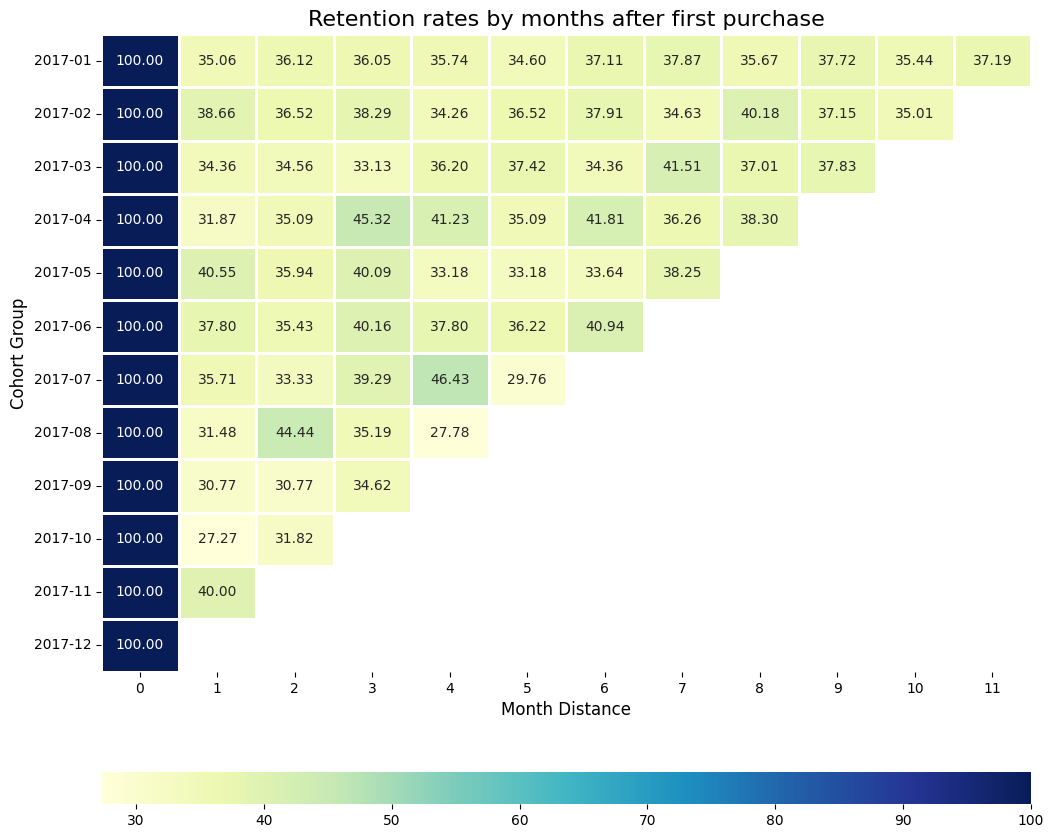

In [14]:
grid = {
  'height_ratios' : (20,1), # sets the height ratio between subplot 1 and subplot 2
  'hspace' : 0.3 # sets the spacing between subplot 1 and subplot 2
}

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(12,10), gridspec_kw=grid)

cohort_heatmap = sns.heatmap(
  data = cohort_pivot, # data
  annot=True, # displays annotations/values
  fmt='.2f', # annotation format --> 2 decimal places
  cmap='YlGnBu', # sets the color palette
  ax = ax_top, # places the heatmap in the top subplot
  cbar_ax = ax_bottom, # places the colorbar in the bottom subplot
  cbar_kws = {'orientation':'horizontal'}, # changes the orientation of the colorbar to horizontal
  linewidths=1
)

cohort_heatmap.set_title('Retention rates by months after first purchase', size=16)
cohort_heatmap.set_xlabel('Month Distance', size=12)
cohort_heatmap.set_ylabel('Cohort Group', size=12)

plt.show()

**Insight:**

- Darker colors indicate a higher number of retained customers.
- Example: 46.43% of customers who made their first transaction in July 2017 remained with us in the fourth month (November).
- Lighter colors indicate a lower number of retained customers.
- Example: Only 27.27% of customers who made their first transaction in October 2017 remained with us in the following month (November).
- Overall, the number of customers from month 1 onward was fairly stable for each cohort.
- In December, the majority of cohorts experienced an increase in customer numbers, except for the February, July, and August cohorts.
- The highest percentage of retained customers occurred in the July cohort (2017-07) in month 4, at 46.43%.
- The lowest percentage of retained customers occurred in the October cohort (2017-10) in month 1, at 27.27%.

In [15]:
top3 = cohort[cohort['period_distance']==1].sort_values('percentage', ascending=False).head(3).reset_index(drop=True)
top3

,cohort_group,transaction_period,n_customers,period_distance,cohort_size,percentage
0,2017-05,2017-06,88,1,217,40.55
1,2017-11,2017-12,6,1,15,40.00
2,2017-02,2017-03,307,1,794,38.66


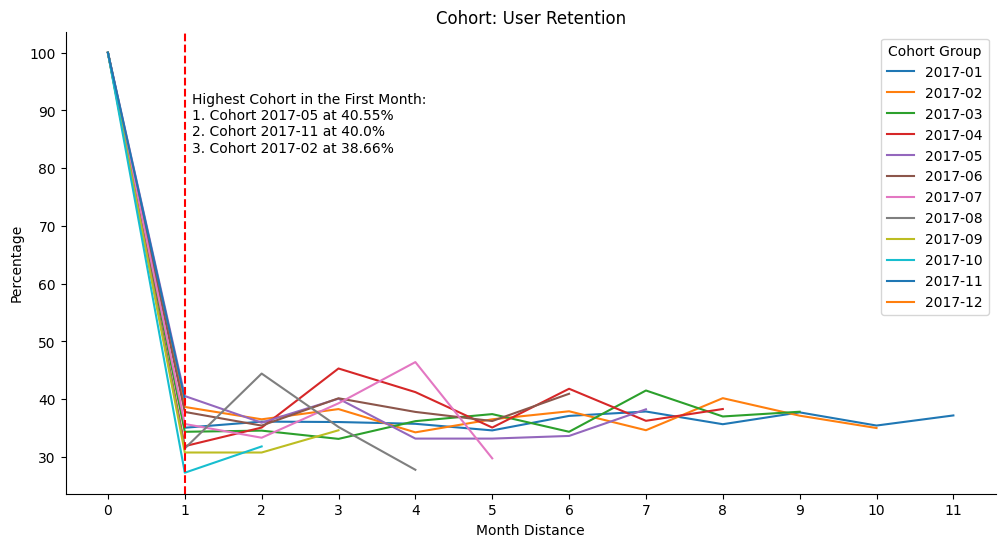

In [16]:
# creates the Figure and adds a single Axes object
fig, ax = plt.subplots(figsize=(12, 6))

for cohort in cohort_pivot.index:
  ax.plot(
      cohort_pivot.columns,
      cohort_pivot.loc[cohort],
      label=cohort
  )

ax.set(
    xlabel='Month Distance',
    ylabel='Percentage',
    title='Cohort: User Retention',
    xticks=np.arange(len(cohort_pivot))
)

ax.legend(loc='upper right', title='Cohort Group')

for spine in ['top', 'right']:
  ax.spines[spine].set_visible(False)

plt.axvline(x=1, linestyle='--', color='red')

# add text
text_lineplot = f'''
Highest Cohort in the First Month:
1. Cohort {top3.loc[0, 'cohort_group']} at {top3.loc[0, 'percentage']}%
2. Cohort {top3.loc[1, 'cohort_group']} at {top3.loc[1, 'percentage']}%
3. Cohort {top3.loc[2, 'cohort_group']} at {top3.loc[2, 'percentage']}%
'''

plt.text(x=1.1, y=80, s=text_lineplot)

plt.show()

### **Number 3**

Next, the marketing department asks you to create customer segmentation for 2017. Create an RFM analysis based on the data provided. How was BikeStore's customer segmentation for 2017?

In [17]:
df_clean

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,transaction_period,cohort_group
0,1,2,2950,2017-02-25,False,Approved,Solex,Standard,medium,medium,71.49,$53.62,41245.0,2017-02,2017-02
1,2,3,3120,2017-05-21,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,$388.92,41701.0,2017-05,2017-01
2,3,37,402,2017-10-16,False,Approved,OHM Cycles,Standard,low,medium,1793.43,$248.82,36361.0,2017-10,2017-01
3,4,88,3135,2017-08-31,False,Approved,Norco Bicycles,Standard,medium,medium,1198.46,$381.10,36145.0,2017-08,2017-02
4,5,78,787,2017-10-01,True,Approved,Giant Bicycles,Standard,medium,large,1765.30,$709.48,42226.0,2017-10,2017-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,51,1018,2017-06-24,True,Approved,OHM Cycles,Standard,high,medium,2005.66,"$1,203.40",37823.0,2017-06,2017-01
19996,19997,41,127,2017-11-09,True,Approved,Solex,Road,medium,medium,416.98,$312.74,35560.0,2017-11,2017-01
19997,19998,87,2284,2017-04-14,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,$44.71,40410.0,2017-04,2017-04
19998,19999,6,2764,2017-07-03,False,Approved,OHM Cycles,Standard,high,medium,227.88,$136.73,38216.0,2017-07,2017-02


In [18]:
import datetime

# Determining analysis date
analysis_date = df_clean['transaction_date'].max() + datetime.timedelta(1)
analysis_date

Timestamp('2017-12-31 00:00:00')

In [19]:
df_customer = df.groupby('customer_id', as_index=False).agg(
    customer_age = ('transaction_date', lambda x: (analysis_date-x.min()).days),
    recency =  ('transaction_date', lambda x: (analysis_date-x.max()).days),
    frequency = ('transaction_id', lambda x: x.nunique()),
    monetary =  ('list_price', 'sum'),
    avg_spend_per_product = ('list_price', 'mean'),
)

df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product
1945,1949,325,30,7,8547.61,1221.087143
3363,3371,336,42,9,8400.31,933.367778
2649,2654,318,109,9,9905.20,1100.577778
1880,1884,360,25,7,6672.00,953.142857
2768,2774,334,85,5,4479.04,895.808000


### `RFM Segmentation`

**Recency Segmentation**

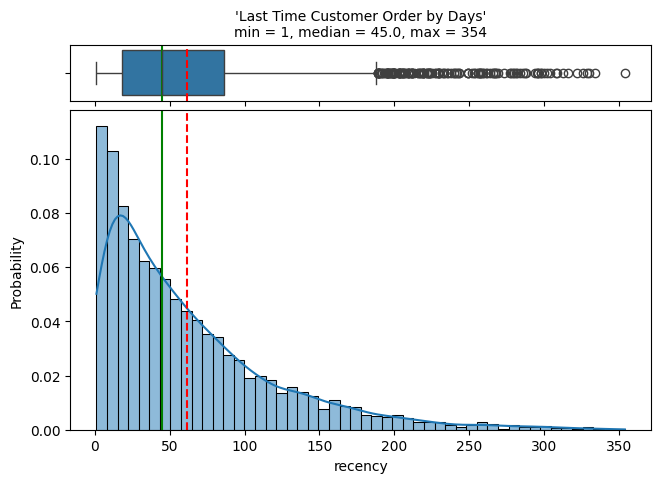

,recency
0.25,18.0
0.50,45.0
0.75,86.0


In [22]:
# Visualization

fig, (ax1, ax2) = plt.subplots(2, sharex = True, figsize = (7.5,5),
                                   gridspec_kw={"height_ratios": (.15, .85),
                                               "hspace": 0.05})

ax1.set_title(f"""'Last Time Customer Order by Days'
min = {df_customer['recency'].min()}, median = {df_customer['recency'].median()}, max = {df_customer['recency'].max()}""", color = "black", fontsize=10)

sns.boxplot(x = df_customer['recency'], ax = ax1)
ax1.axvline(df_customer['recency'].mean(), color='r', linestyle='--')
ax1.axvline(df_customer['recency'].median(), color='g', linestyle='-')
ax1.set(xlabel = "")
sns.histplot(data = df_customer['recency'], ax = ax2, stat = "probability", kde=True, bins=50)
ax2.axvline(df_customer['recency'].mean(), color='r', linestyle='--')
ax2.axvline(df_customer['recency'].median(), color='g', linestyle='-')
plt.show()

display(df_customer['recency'].quantile([0.25, 0.5, 0.75]))

Based on the distribution above, we will group customers based on their recency into four groups:
- 4 (Active): Transactions made within the last 18 days or less
- 3 (Warm): Transactions made within the last 18 to 45 days
- 2 (Cold): Transactions made within the last 45 to 86 days
- 1 (Inactive): Transactions made within the last 86 days or more

In [23]:
# Recency segmentation using quartiles
label_r = range(4, 0, -1)
group_r = pd.qcut(df_customer['recency'], q=4, labels=label_r).astype('int')
df_customer['r_score'] = group_r.values
df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product,r_score
1945,1949,325,30,7,8547.61,1221.087143,3
3363,3371,336,42,9,8400.31,933.367778,3
2649,2654,318,109,9,9905.20,1100.577778,1
1880,1884,360,25,7,6672.00,953.142857,3
2768,2774,334,85,5,4479.04,895.808000,2


**Frequency Segmentation**

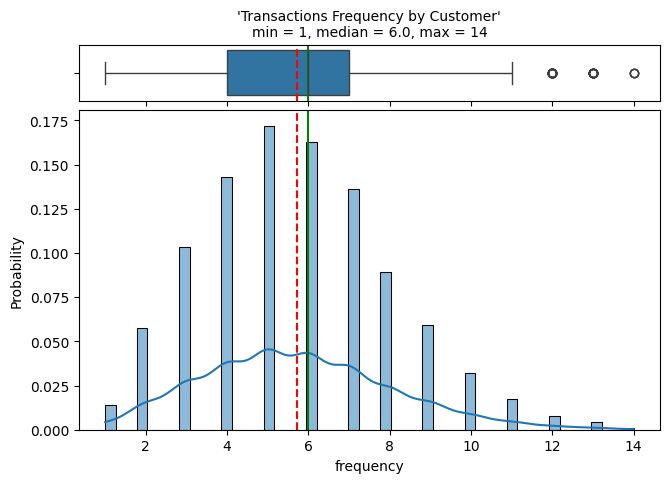

,frequency
0.25,4.0
0.50,6.0
0.75,7.0


In [24]:
# Visualization
fig, (ax1, ax2) = plt.subplots(2, sharex = True, figsize = (7.5,5),
                                   gridspec_kw={"height_ratios": (.15, .85),
                                               "hspace": 0.05})

ax1.set_title(f"""'Transactions Frequency by Customer'
min = {df_customer['frequency'].min()}, median = {df_customer['frequency'].median()}, max = {df_customer['frequency'].max()}""", color = "black", fontsize=10)

sns.boxplot(x = df_customer['frequency'], ax = ax1)
ax1.axvline(df_customer['frequency'].mean(), color='r', linestyle='--')
ax1.axvline(df_customer['frequency'].median(), color='g', linestyle='-')
ax1.set(xlabel = "")
sns.histplot(data = df_customer['frequency'], ax = ax2, stat = "probability", kde=True, bins=50)
ax2.axvline(df_customer['frequency'].mean(), color='r', linestyle='--')
ax2.axvline(df_customer['frequency'].median(), color='g', linestyle='-')
plt.show()

display(df_customer['frequency'].quantile([0.25, 0.5, 0.75]))

Based on the distribution above, we will group customers based on their frequency into four groups, referring to the number of transactions we determined:
- 4 (Loyal): made more than 7 transactions
- 3 (High): made 7 transactions
- 2 (Medium): made 5 to 6 transactions
- 1 (Low): made less than or equal to 4 transactions.

In [25]:
# function to determine f_score
def f_score(x):
    if x <= 4:
        return 1
    elif x <= 6:
        return 2
    elif x <= 7:
        return 3
    else:
        return 4

df_customer['f_score'] = df_customer['frequency'].apply(f_score)

df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product,r_score,f_score
1945,1949,325,30,7,8547.61,1221.087143,3,3
3363,3371,336,42,9,8400.31,933.367778,3,4
2649,2654,318,109,9,9905.20,1100.577778,1,4
1880,1884,360,25,7,6672.00,953.142857,3,3
2768,2774,334,85,5,4479.04,895.808000,2,2


**Monetary Segmentation**

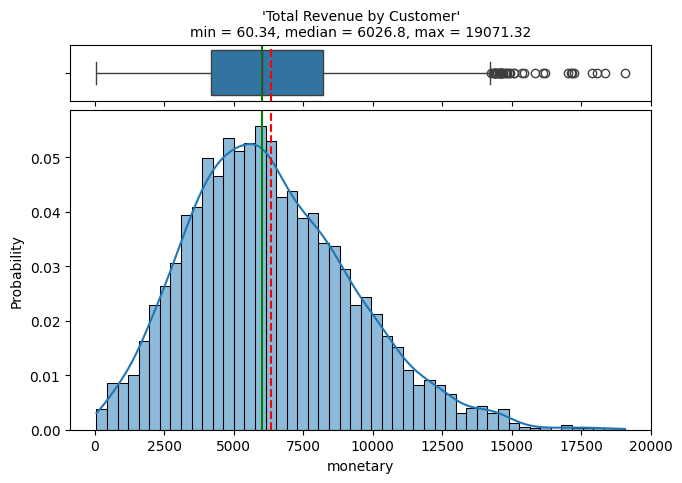

,monetary
0.25,4198.3900
0.50,6026.8000
0.75,8208.8375


In [26]:
# Visualization

fig, (ax1, ax2) = plt.subplots(2, sharex = True, figsize = (7.5,5),
                                   gridspec_kw={"height_ratios": (.15, .85),
                                               "hspace": 0.05})

ax1.set_title(f"""'Total Revenue by Customer'
min = {df_customer['monetary'].min()}, median = {df_customer['monetary'].median()}, max = {df_customer['monetary'].max()}""", color = "black", fontsize=10)

sns.boxplot(x = df_customer['monetary'], ax = ax1)
ax1.axvline(df_customer['monetary'].mean(), color='r', linestyle='--')
ax1.axvline(df_customer['monetary'].median(), color='g', linestyle='-')
ax1.set(xlabel = "")
sns.histplot(data = df_customer['monetary'], ax = ax2, stat = "probability", kde=True, bins=50)
ax2.axvline(df_customer['monetary'].mean(), color='r', linestyle='--')
ax2.axvline(df_customer['monetary'].median(), color='g', linestyle='-')
plt.show()

display(df_customer['monetary'].quantile([0.25, 0.5, 0.75]))

Based on the distribution above, we will group customers based on their monetary value into four groups:
- 4 (Top Spender): Transactions exceeding USD 8,208.83
- 3 (High Spender): Transactions between USD 6,026.8 and USD 8,208.83
- 2 (Medium Spender): Transactions between USD 4,198.39 and USD 6,026.83
- 1 (Low Spender): Transactions less than USD 4,198.39

In [27]:
# Monetary segmentation using quartiles
label_m = range(1, 5, 1)
group_m = pd.qcut(df_customer['monetary'], q=4, labels=label_m).astype('int')
df_customer['m_score'] = group_m.values
df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score
1945,1949,325,30,7,8547.61,1221.087143,3,3,4
3363,3371,336,42,9,8400.31,933.367778,3,4,4
2649,2654,318,109,9,9905.20,1100.577778,1,4,4
1880,1884,360,25,7,6672.00,953.142857,3,3,3
2768,2774,334,85,5,4479.04,895.808000,2,2,2


**RFM Segmentation**

Next, we will combine the r score, f score, and m_score into rfm_score.

In [28]:
df_customer['rfm_score'] = df_customer['r_score'] + df_customer['f_score'] + df_customer['m_score']
df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score,rfm_score
1945,1949,325,30,7,8547.61,1221.087143,3,3,4,10
3363,3371,336,42,9,8400.31,933.367778,3,4,4,11
2649,2654,318,109,9,9905.20,1100.577778,1,4,4,9
1880,1884,360,25,7,6672.00,953.142857,3,3,3,9
2768,2774,334,85,5,4479.04,895.808000,2,2,2,6


Then we will group it into 4 segments with the following provisions:

In [29]:
def rfm_level(df):
    if df['rfm_score'] >= 11:
        return 'Platinum'
    elif ((df['rfm_score'] >= 8) and (df['rfm_score'] < 11)):
        return 'Gold'
    elif ((df['rfm_score'] >= 6) and (df['rfm_score'] < 8)):
        return 'Silver'
    else:
        return 'Bronze'

df_customer['rfm_level'] = df_customer.apply(rfm_level, axis=1)
df_customer.sample(5, random_state=42)

,customer_id,customer_age,recency,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score,rfm_score,rfm_level
1945,1949,325,30,7,8547.61,1221.087143,3,3,4,10,Gold
3363,3371,336,42,9,8400.31,933.367778,3,4,4,11,Platinum
2649,2654,318,109,9,9905.20,1100.577778,1,4,4,9,Gold
1880,1884,360,25,7,6672.00,953.142857,3,3,3,9,Gold
2768,2774,334,85,5,4479.04,895.808000,2,2,2,6,Silver


We will try to display it in the form of a visualization as follows:

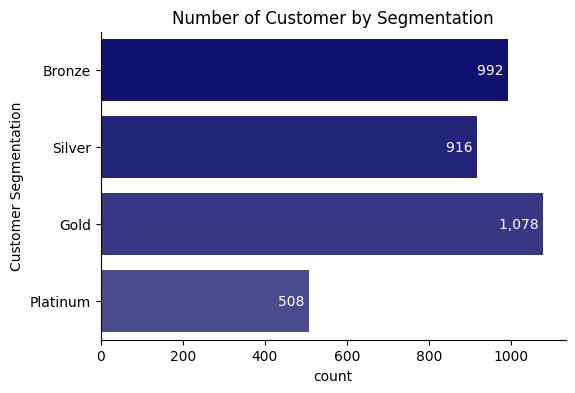

In [31]:
color_palette = sns.blend_palette(['navy', 'lightgrey'], 11)

# Visualization
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.countplot(
    data=df_customer,
    y ='rfm_level',
    palette=color_palette,
    order=['Bronze', 'Silver', 'Gold', 'Platinum']
)

ax.set(
    title = 'Number of Customer by Segmentation',
    ylabel = 'Customer Segmentation'
)

for bar in ax.patches:
    x, y = bar.get_xy()
    ax.text(
        x + bar.get_width(), y + bar.get_height()/2, f'{bar.get_width():,.0f} ',
        va='center', ha='right', color='white'
    )

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

In [32]:
# RFM segmentation for analysis
rfm_segment = df_customer.groupby(['rfm_level']).agg(
    n_customer = ('customer_id', 'count'),
    median_recency =  ('recency', 'median'),
    median_freq = ('frequency', 'median'),
    median_monetary =  ('monetary', 'median'),
).sort_values(by='median_monetary', ascending=False)

rfm_segment

,n_customer,median_recency,median_freq,median_monetary
rfm_level,,,,
Platinum,508,15.0,9.0,10238.850
Gold,1078,32.0,7.0,7507.585
Silver,916,47.5,5.0,5471.010
Bronze,992,99.0,3.0,3540.640


From the visualization and table above, we can summarize and recommend the following:

| Segment | Description | Strategy |
| --- | --- | --- |
| Platinum | Purchased in the last 15 days with a very high transaction value and frequency (~9). | Offer a gift. Offer other, more exclusive products and provide personal recommendations.
| Gold | Purchased in the last month with a fairly high transaction value but moderate frequency (~7). | Focus on getting customers to make repeat purchases. Offer a membership or loyalty program.
| Silver | Purchased in the last 1.5 months with a moderate transaction value and frequency (~5). | Provide a voucher. Contact directly if necessary.
| Bronze | Purchased in the last 3 months or more with the lowest transaction value and frequency. | Rekindle interest with campaigns, discounts, and limited-time offers.

In [33]:
# Visualization # Using Plotly
import plotly.express as px

color_map = {'Bronze' : 'blue', 'Silver' : 'green', 'Gold' : 'orange', 'Platinum' : 'red'}

fig = px.scatter_3d(
    df_customer,
    x='recency',
    y='frequency',
    z='monetary',
    color='rfm_level',
    color_discrete_map=color_map,
)

fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                   legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")


